# **Общие рекомендации**

* Решения заданий ожидаются в формате ноутбука (Jupyter/Colab).

* Формулы желательно оформлять с использование [latex-markdown](https://colab.research.google.com/notebooks/markdown_guide.ipynb).

* Задание 8 не влияет на оценивание, но может быть выполнено вами ради интереса и получения математически-эстетического удовольствия ☺️.

# **Задания**

Решения оформлены в Markdown + LaTeX, вычисления и проверки — в **SymPy** (символьно, точной арифметикой) и **NumPy** (численно).
Нумерация решений соответствует нумерации заголовков заданий выше.

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

sp.init_printing(use_latex='mathjax')   # рендер формул SymPy через MathJax (LaTeX)

---

### Задание 1.


Известно, что $g(x) = 2^x + 1$. Вычислите численное значение $g(g(2))$.



**Решение 1.**

Композиция вычисляется «изнутри наружу»: сначала внутренний вызов, его результат подставляется во внешний.

Внутренний вызов:
$\displaystyle g(2)=2^{2}+1=4+1=5.$

Внешний вызов от полученного значения:
$\displaystyle g(g(2))=g(5)=2^{5}+1=32+1=33.$

**Ответ:** $g(g(2))=33$.

In [2]:
def g(x):
    return 2**x + 1

g(2), g(g(2))

(5, 33)

---

### Задание 2.

Даны матрицы:

$\displaystyle
A = \begin{pmatrix}
2 & -4 \\
3 & 5 \\
-1 & 0
\end{pmatrix}, \quad
B = \begin{pmatrix}
1 & 2 & 7 \\
-3 & -4 & 0 \\
5 & 2 & 1
\end{pmatrix}, \quad
C = \begin{pmatrix}
6 & -3 & 9 \\
4 & -5 & 2 \\
8 & 1 & 5
\end{pmatrix}.
$

Посчитайте матрицу $D = A^T C - 2A^T B^T$.  
Приведите полную последовательность вычислений.

*Желательно оформить решение прямо в ноутбуке в текстовой ячейке, используя [latex-markdown](https://colab.research.google.com/notebooks/markdown_guide.ipynb).*

**Решение 2.**

Проверим согласованность размеров: $A$ имеет размер $3\times2$, значит $A^\top$ — $2\times3$; $C$ и $B^\top$ — $3\times3$.
Оба произведения дают матрицы $2\times3$, поэтому разность $D$ определена и имеет размер $2\times3$.

**Шаг 1.** Транспонируем $A$ (строки становятся столбцами):
$\displaystyle A^\top=\begin{pmatrix}2&3&-1\\-4&5&0\end{pmatrix}.$

**Шаг 2.** Считаем $A^\top C$ — элемент $(i,j)$ есть скалярное произведение $i$-й строки $A^\top$ на $j$-й столбец $C$:
$\displaystyle \begin{aligned} (1,1):\;& 2\cdot6+3\cdot4+(-1)\cdot8=12+12-8=16, & (1,2):\;& 2\cdot(-3)+3\cdot(-5)+(-1)\cdot1=-6-15-1=-22,\\ (1,3):\;& 2\cdot9+3\cdot2+(-1)\cdot5=18+6-5=19, & (2,1):\;& (-4)\cdot6+5\cdot4+0\cdot8=-24+20+0=-4,\\ (2,2):\;& (-4)\cdot(-3)+5\cdot(-5)+0\cdot1=12-25+0=-13, & (2,3):\;& (-4)\cdot9+5\cdot2+0\cdot5=-36+10+0=-26. \end{aligned}$

$\displaystyle A^\top C=\begin{pmatrix}16&-22&19\\-4&-13&-26\end{pmatrix}.$

**Шаг 3.** Транспонируем $B$ и считаем $A^\top B^\top$:
$\displaystyle B^\top=\begin{pmatrix}1&-3&5\\2&-4&2\\7&0&1\end{pmatrix},$

$\displaystyle \begin{aligned} (1,1):\;& 2\cdot1+3\cdot2+(-1)\cdot7=1, & (1,2):\;& 2\cdot(-3)+3\cdot(-4)+(-1)\cdot0=-18, & (1,3):\;& 2\cdot5+3\cdot2+(-1)\cdot1=15,\\ (2,1):\;& (-4)\cdot1+5\cdot2+0\cdot7=6, & (2,2):\;& (-4)\cdot(-3)+5\cdot(-4)+0\cdot0=-8, & (2,3):\;& (-4)\cdot5+5\cdot2+0\cdot1=-10. \end{aligned}$

$\displaystyle A^\top B^\top=\begin{pmatrix}1&-18&15\\6&-8&-10\end{pmatrix}.$

**Шаг 4.** Умножаем на $2$ и вычитаем поэлементно:
$\displaystyle D=\begin{pmatrix}16&-22&19\\-4&-13&-26\end{pmatrix}-2\begin{pmatrix}1&-18&15\\6&-8&-10\end{pmatrix} =\begin{pmatrix}16-2&-22+36&19-30\\-4-12&-13+16&-26+20\end{pmatrix}.$

**Ответ:**
$\displaystyle D=\begin{pmatrix}14&14&-11\\-16&3&-6\end{pmatrix}.$

*Замечание:* «свернуть» выражение до $A^\top(C-2B^\top)$ здесь можно (это верно по дистрибутивности), но $A^\top B^\top=(BA)^\top$ не работает — $BA$ не определено, размеры $3\times3$ и $3\times2$ несовместны в этом порядке.

In [3]:
A = sp.Matrix([[2, -4], [3, 5], [-1, 0]])
B = sp.Matrix([[1, 2, 7], [-3, -4, 0], [5, 2, 1]])
C = sp.Matrix([[6, -3, 9], [4, -5, 2], [8, 1, 5]])

print('A^T C   =')
sp.pprint(A.T * C)
print('A^T B^T =')
sp.pprint(A.T * B.T)

D = A.T * C - 2 * A.T * B.T
D

A^T C   =
⎡16  -22  19 ⎤
⎢            ⎥
⎣-4  -13  -26⎦
A^T B^T =
⎡1  -18  15 ⎤
⎢           ⎥
⎣6  -8   -10⎦


⎡14   14  -11⎤
⎢            ⎥
⎣-16  3   -6 ⎦

---

### Задание 3.

Дано выражение:

$$
3 \cdot \begin{pmatrix}
x & 2 & 3 \\
-1 & y & 4
\end{pmatrix}
+ 2 \cdot \begin{pmatrix}
1 & 2 & -5 \\
2 & -6 & z
\end{pmatrix}
= \begin{pmatrix}
8 & v & -1 \\
1 & 6 & 4
\end{pmatrix}.
$$

Найдите значения $(x, y, z)$ и $v$, при которых выражение верно.

**Решение 3.**

Умножение на число и сложение матриц выполняются поэлементно, поэтому левая часть равна
$\displaystyle \begin{pmatrix}3x&6&9\\-3&3y&12\end{pmatrix}+\begin{pmatrix}2&4&-10\\4&-12&2z\end{pmatrix} =\begin{pmatrix}3x+2&10&-1\\1&3y-12&12+2z\end{pmatrix}.$

Две матрицы равны тогда и только тогда, когда равны все их соответственные элементы. Это даёт систему из шести скалярных уравнений:
$\displaystyle \begin{aligned} (1,1):\;& 3x+2=8 &&\Rightarrow\; x=2,\\ (1,2):\;& 10=v &&\Rightarrow\; v=10,\\ (1,3):\;& -1=-1 &&\text{— тождество, неизвестных нет},\\ (2,1):\;& 1=1 &&\text{— тождество, неизвестных нет},\\ (2,2):\;& 3y-12=6 &&\Rightarrow\; y=6,\\ (2,3):\;& 12+2z=4 &&\Rightarrow\; z=-4. \end{aligned}$

Позиции $(1,3)$ и $(2,1)$ выполняются автоматически, значит система совместна, и решение единственно.

**Ответ:** $(x,y,z)=(2,\,6,\,-4)$, $v=10$.

In [4]:
x, y, z, v = sp.symbols('x y z v')

L = 3 * sp.Matrix([[x, 2, 3], [-1, y, 4]]) + 2 * sp.Matrix([[1, 2, -5], [2, -6, z]])
R = sp.Matrix([[8, v, -1], [1, 6, 4]])

print('левая часть ='); sp.pprint(L)
sp.solve(list(L - R), [x, y, z, v], dict=True)

левая часть =
⎡3⋅x + 2     10        -1   ⎤
⎢                           ⎥
⎣   1     3⋅y - 12  2⋅z + 12⎦


[{v: 10, x: 2, y: 6, z: -4}]

---

### Задания 4-5.

На координатной плоскости отмечено 3 точки:

<img src="https://github.com/dmi3eva/resources/blob/main/2026-04-27_OLS-home.png?raw=true" width="500">

**Цель:**

Найти прямую, проходящую через (0, 0), для которой минимальна:

3) Сумма отклонений от данных точек по `у`

4) Сумма квадратов отклонений от данных точек по `у`


**Пример:**

Для данной синей прямой, суммарное отклонение по `y` составляет 5 + 0 + 8 = 13.

<img src="https://github.com/dmi3eva/resources/blob/main/2026-04-27_OLS-example.png?raw=true" width="500">



**Задание:**

Для каждого из пунктов опишите следующие шаги своего решения:

* **Шаг 1.** Введите и опишите параметры, которые могут задавать прямую. Постарайтесь, чтобы их было как можно меньше.

* **Шаг 2.** Запишите целевую функцию, зависящую от этих параметров.

* **Шаг 3.** Подберите параметры, при которых достигается минимальное значение данной целевой функции. Вы можете использовать производные или графический метод (например, с использованием сервиса https://www.geogebra.org). Важно найти именно точное решение.

* **Шаг 4.** Нарисуйте хотя бы одну прямую, соответствующую найденным параметрам. Рисунок можно нарисовать, используя графические библиотеки или https://www.geogebra.org. Также вы можете просто вставить фото своего чертежа.

**Исходные данные.**

С рисунка снимаем координаты трёх точек: $(-3,\,2)$, $(2,\,2)$, $(5,\,-3)$.

Проверим их по примеру из условия: для синей прямой $y=x$ (она проходит через $(0,0)$ и через точку $(2,2)$) отклонения по $y$ равны
$|2-(-3)|=5$, $|2-2|=0$, $|-3-5|=8$, в сумме $5+0+8=13$ — ровно как в условии. Значит координаты сняты верно.

---

### Задание 4. Минимум суммы модулей отклонений (метод наименьших модулей)

**Шаг 1. Параметры прямой.**

Прямая обязана проходить через начало координат. Общее уравнение прямой через $(0,0)$ — это $ax+by=0$, но такая запись избыточна (пара $(a,b)$ определена с точностью до множителя). Невертикальную прямую через начало координат однозначно задаёт **один** параметр — угловой коэффициент $k$:
$\displaystyle y=kx,\qquad k\in\mathbb{R}.$

Вертикальную прямую $x=0$ рассматривать нельзя: для неё отклонение по $y$ не определено (у прямой нет значения $y$ в точках $x\neq0$). Итого — один параметр.

**Шаг 2. Целевая функция.**

Отклонение по $y$ для точки $(x_i,y_i)$ — это $|y_i-kx_i|$ (в примере отклонения складывались как неотрицательные величины: $5+0+8$). Значит
$\displaystyle S_1(k)=\sum_{i=1}^{3}\bigl|y_i-kx_i\bigr| =|2+3k|+|2-2k|+|-3-5k| =|2+3k|+|2-2k|+|3+5k|.$

**Шаг 3. Минимизация.**

$S_1$ — сумма модулей линейных функций, то есть **кусочно-линейная выпуклая** функция. Производной в точках излома нет, поэтому приравнять $S_1'(k)=0$ не получится; минимум достигается в одной из точек излома. Изломы там, где обнуляется очередной модуль, то есть при
$\displaystyle k=t_i=\frac{y_i}{x_i}:\qquad t_1=-\tfrac23,\quad t_2=1,\quad t_3=-\tfrac35.$

Удобно переписать целевую функцию, вынеся $|x_i|$ из каждого модуля:
$\displaystyle S_1(k)=\sum_i |x_i|\cdot\Bigl|\frac{y_i}{x_i}-k\Bigr| =\sum_i w_i\,|t_i-k|,\qquad w_i=|x_i|.$

Это классическая задача о **взвешенной медиане**: минимум суммы $\sum w_i|t_i-k|$ достигается в такой точке $t_i$, где накопленный вес впервые достигает половины суммарного. Упорядочим наклоны по возрастанию:

| $t_i$ | $-\tfrac23\approx-0.667$ | $-\tfrac35=-0.6$ | $1$ |
|---|---|---|---|
| вес $w_i=\lvert x_i\rvert$ | $3$ | $5$ | $2$ |
| накопленный вес | $3$ | $8$ | $10$ |

Суммарный вес $\sum w_i=10$, половина — $5$. До $t=-\tfrac35$ накоплено $3<5$, вместе с ним $8>5$, поэтому взвешенная медиана — это $\boxed{k=-\tfrac35}$, и минимум единственный (строгое неравенство с обеих сторон).

Тот же вывод — прямой проверкой значений во всех точках излома (сравнивать больше не с чем: между изломами функция линейна):
$\displaystyle S_1\!\left(-\tfrac23\right)=0+\tfrac{10}{3}+\tfrac13=\tfrac{11}{3}\approx3.667,\qquad S_1\!\left(-\tfrac35\right)=\tfrac15+\tfrac{16}{5}+0=\tfrac{17}{5}=3.4,\qquad S_1(1)=5+0+8=13.$

**Ответ:** $k=-\dfrac35$, прямая $y=-\dfrac35x$, минимальная сумма отклонений $S_1=\dfrac{17}{5}=3.4$.

Содержательно результат означает, что прямая проходит **точно через одну из точек** — через $(5,-3)$: у метода наименьших модулей оптимум всегда достигается на такой «опорной» точке, а не между точками.

**Шаг 4.** Чертёж — в ячейке ниже (вместе с задачей 5).

---

### Задание 5. Минимум суммы квадратов отклонений (МНК)

**Шаг 1.** Параметр тот же один: $y=kx$.

**Шаг 2.** Целевая функция:
$\displaystyle S_2(k)=\sum_{i=1}^{3}\bigl(y_i-kx_i\bigr)^2 =(2+3k)^2+(2-2k)^2+(-3-5k)^2.$

Раскроем скобки:
$\displaystyle S_2(k)=(9+4+25)k^2+2(3\cdot2-2\cdot2+5\cdot3)k+(4+4+9)=38k^2+34k+17.$

**Шаг 3.** Это парабола с положительным старшим коэффициентом, гладкая всюду, поэтому минимум — в единственной стационарной точке:
$\displaystyle \frac{dS_2}{dk}=-2\sum_i x_i\,(y_i-kx_i)=76k+34=0 \quad\Longrightarrow\quad k=-\frac{34}{76}=-\frac{17}{38}\approx-0.4474.$

Вторая производная $S_2''=2\sum_i x_i^2=76>0$ — действительно минимум. В общем виде это и есть формула однопараметрического МНК:
$\displaystyle k_{\min}=\frac{\sum_i x_iy_i}{\sum_i x_i^2}=\frac{-6+4-15}{9+4+25}=-\frac{17}{38}.$

Минимальное значение:
$\displaystyle S_2^{\min}=\sum_i y_i^2-\frac{\bigl(\sum_i x_iy_i\bigr)^2}{\sum_i x_i^2}=17-\frac{289}{38}=\frac{357}{38}\approx9.395.$

**Ответ:** $k=-\dfrac{17}{38}$, прямая $y=-\dfrac{17}{38}x$, минимальная сумма квадратов $S_2=\dfrac{357}{38}\approx9.395$.

**Шаг 4.** Чертёж — ниже.

Обратите внимание: два критерия дают **разные** прямые. Квадрат сильнее штрафует большие промахи, поэтому МНК-прямая «подтягивается» к далёкой точке $(5,-3)$ не так жёстко, а компромиссно разворачивается в сторону остальных двух; решение по модулям, наоборот, садится ровно на одну из точек.

In [5]:
pts = [(-3, 2), (2, 2), (5, -3)]          # координаты, снятые с рисунка
X = np.array([xi for xi, _ in pts], dtype=float)
Y = np.array([yi for _, yi in pts], dtype=float)

k = sp.symbols('k', real=True)
S1 = sum(sp.Abs(yi - k * xi) for xi, yi in pts)      # сумма модулей
S2 = sum((yi - k * xi)**2 for xi, yi in pts)         # сумма квадратов

print('S1(k) =', S1)
print('S2(k) =', sp.expand(S2))

# Задание 4: значения в точках излома t_i = y_i / x_i
breaks = sorted({sp.Rational(yi, xi) for xi, yi in pts})
for t in breaks:
    print(f'S1({t}) = {S1.subs(k, t)} = {float(S1.subs(k, t)):.4f}')

k1 = min(breaks, key=lambda t: S1.subs(k, t))

# Задание 5: стационарная точка параболы
k2 = sp.solve(sp.diff(S2, k), k)[0]
print('\nk (модули)   =', k1, '=', float(k1), '  S1 =', S1.subs(k, k1), '=', float(S1.subs(k, k1)))
print('k (квадраты) =', k2, '=', float(k2), '  S2 =', S2.subs(k, k2), '=', float(S2.subs(k, k2)))
print('вторая производная S2 =', sp.diff(S2, k, 2))

S1(k) = Abs(2*k - 2) + Abs(3*k + 2) + Abs(5*k + 3)
S2(k) = 38*k**2 + 34*k + 17
S1(-2/3) = 11/3 = 3.6667
S1(-3/5) = 17/5 = 3.4000
S1(1) = 13 = 13.0000

k (модули)   = -3/5 = -0.6   S1 = 17/5 = 3.4
k (квадраты) = -17/38 = -0.4473684210526316   S2 = 357/38 = 9.394736842105264
вторая производная S2 = 76


In [6]:
# Численная проверка обоих минимумов грубой силой по сетке
grid = np.linspace(-2, 2, 400_001)
f1 = np.abs(Y[None, :] - grid[:, None] * X[None, :]).sum(axis=1)
f2 = ((Y[None, :] - grid[:, None] * X[None, :])**2).sum(axis=1)

print(f'модули:   k = {grid[f1.argmin()]:.5f} (точно {float(k1):.5f}),  S1 = {f1.min():.5f}')
print(f'квадраты: k = {grid[f2.argmin()]:.5f} (точно {float(k2):.5f}),  S2 = {f2.min():.5f}')

модули:   k = -0.60000 (точно -0.60000),  S1 = 3.40000
квадраты: k = -0.44737 (точно -0.44737),  S2 = 9.39474


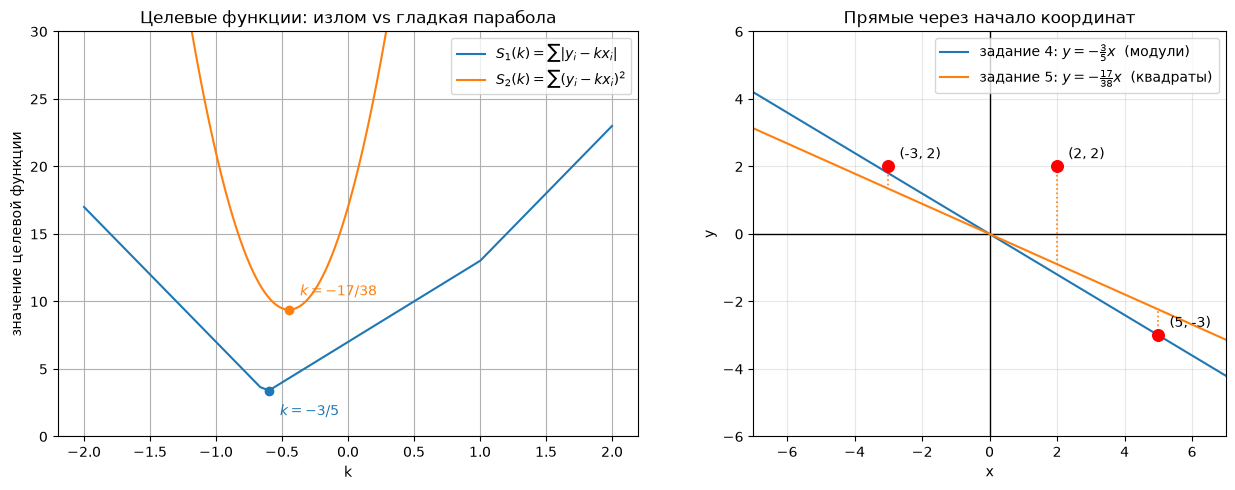

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# --- слева: целевые функции
ax[0].plot(grid, f1, label=r'$S_1(k)=\sum|y_i-kx_i|$')
ax[0].plot(grid, f2, label=r'$S_2(k)=\sum(y_i-kx_i)^2$')
ax[0].plot(float(k1), float(S1.subs(k, k1)), 'o', color='tab:blue')
ax[0].plot(float(k2), float(S2.subs(k, k2)), 'o', color='tab:orange')
ax[0].annotate(r'$k=-3/5$', (float(k1), float(S1.subs(k, k1))), textcoords='offset points',
               xytext=(8, -18), color='tab:blue')
ax[0].annotate(r'$k=-17/38$', (float(k2), float(S2.subs(k, k2))), textcoords='offset points',
               xytext=(8, 10), color='tab:orange')
ax[0].set_xlabel('k'); ax[0].set_ylabel('значение целевой функции')
ax[0].set_title('Целевые функции: излом vs гладкая парабола')
ax[0].set_ylim(0, 30); ax[0].grid(True); ax[0].legend()

# --- справа: точки и найденные прямые
xs = np.linspace(-7, 7, 100)
ax[1].axhline(0, color='k', lw=1); ax[1].axvline(0, color='k', lw=1)
ax[1].scatter(X, Y, color='red', zorder=5, s=70)
for xi, yi in zip(X, Y):
    ax[1].annotate(f'({xi:.0f}, {yi:.0f})', (xi, yi), textcoords='offset points', xytext=(8, 6))
ax[1].plot(xs, float(k1) * xs, color='tab:blue', label=r'задание 4: $y=-\frac{3}{5}x$  (модули)')
ax[1].plot(xs, float(k2) * xs, color='tab:orange', label=r'задание 5: $y=-\frac{17}{38}x$  (квадраты)')
for xi, yi in zip(X, Y):        # вертикальные отклонения до МНК-прямой
    ax[1].plot([xi, xi], [yi, float(k2) * xi], ls=':', color='tab:orange', lw=1.2)
ax[1].set_xlim(-7, 7); ax[1].set_ylim(-6, 6); ax[1].set_aspect('equal')
ax[1].set_xlabel('x'); ax[1].set_ylabel('y')
ax[1].set_title('Прямые через начало координат')
ax[1].grid(True, alpha=.3); ax[1].legend(loc='upper right')

plt.tight_layout(); plt.show()

---

### Задание 6.



* Запишите матрично-векторное уравнение $Ax = b$ в виде системы линейных уравнений.

* Решите его любым способом, найдя **вектор** $x$. Решение опишите.



$\displaystyle
A =
 \begin{pmatrix}
  1 & 2 & 4 \\
  2 & 1 & -1 \\
  1 & -1 & 1 \\
 \end{pmatrix}
$

$\displaystyle
 b =
  \begin{pmatrix}
  3 \\
  -9 \\
  0 \\
 \end{pmatrix}
$

**Решение 6.**

**Запись в виде системы.** Произведение $Ax$ — это вектор, $i$-я компонента которого равна скалярному произведению $i$-й строки $A$ на $x=(x_1,x_2,x_3)^\top$. Приравнивая покомпонентно к $b$, получаем
$\displaystyle \left\{\begin{aligned} x_1+2x_2+4x_3&=3,\\ 2x_1+\;\,x_2-\;\,x_3&=-9,\\ x_1-\;\,x_2+\;\,x_3&=0. \end{aligned}\right.$

**Решение методом Гаусса.** Работаем с расширенной матрицей $(A\,|\,b)$:
$\displaystyle \left(\begin{array}{ccc|c} 1&2&4&3\\ 2&1&-1&-9\\ 1&-1&1&0 \end{array}\right) \xrightarrow[\;R_3-R_1\;]{\;R_2-2R_1\;} \left(\begin{array}{ccc|c} 1&2&4&3\\ 0&-3&-9&-15\\ 0&-3&-3&-3 \end{array}\right) \xrightarrow[\;R_3/(-3)\;]{\;R_2/(-3)\;} \left(\begin{array}{ccc|c} 1&2&4&3\\ 0&1&3&5\\ 0&1&1&1 \end{array}\right) \xrightarrow{\;R_3-R_2\;} \left(\begin{array}{ccc|c} 1&2&4&3\\ 0&1&3&5\\ 0&0&-2&-4 \end{array}\right).$

Обратный ход:
$\displaystyle -2x_3=-4\;\Rightarrow\;x_3=2;\qquad x_2=5-3x_3=5-6=-1;\qquad x_1=3-2x_2-4x_3=3+2-8=-3.$

**Проверка** подстановкой в исходную систему:
$\displaystyle \begin{aligned} -3+2\cdot(-1)+4\cdot2&=-3-2+8=3\;\checkmark\\ 2\cdot(-3)+(-1)-2&=-6-1-2=-9\;\checkmark\\ -3-(-1)+2&=-3+1+2=0\;\checkmark \end{aligned}$

Решение единственно, поскольку $\det A=-18\neq0$ (матрица невырождена, у системы ровно один корень).

**Ответ:**
$\displaystyle x=\begin{pmatrix}-3\\-1\\2\end{pmatrix}.$

In [8]:
A6 = sp.Matrix([[1, 2, 4], [2, 1, -1], [1, -1, 1]])
b6 = sp.Matrix([3, -9, 0])

print('ступенчатый вид (A|b):')
sp.pprint(A6.row_join(b6).rref()[0])
print('det A =', A6.det())

x6 = A6.solve(b6)
print('x =', list(x6), '   проверка A@x - b =', list(A6 * x6 - b6))
print('numpy:', np.linalg.solve(np.array(A6, dtype=float), np.array(b6, dtype=float)))
x6.T

ступенчатый вид (A|b):
⎡1  0  0  -3⎤
⎢           ⎥
⎢0  1  0  -1⎥
⎢           ⎥
⎣0  0  1  2 ⎦
det A = -18
x = [-3, -1, 2]    проверка A@x - b = [0, 0, 0]
numpy: [[-3.]
 [-1.]
 [ 2.]]


[-3  -1  2]

---

### Задание 7.

На рисунке изображена плотность некоторого непрерывного распределения:

<img src="https://github.com/dmi3eva/resources/blob/main/2026-04-27_PDF.png?raw=true" width="250">

**6-1:** Вычислите вероятность попадания случайной величины в интервал от 0 до 0.5 включительно.

**6-2:** Запишите функцию вероятности (CDF) этого распределения.








**Решение 7.**

**Восстановим плотность.** На рисунке плотность — прямая $p(x)=2x$, начинающаяся в нуле, а вне закрашенного треугольника она равна нулю. Правую границу носителя $[0,a]$ находим из условия нормировки (полная площадь под плотностью равна 1):
$\displaystyle \int_0^a 2x\,dx=x^2\Big|_0^a=a^2=1\quad\Rightarrow\quad a=1.$

(То же самое из площади треугольника: основание $a$, высота $2a$, площадь $\tfrac12\cdot a\cdot 2a=a^2=1$.) Итого
$\displaystyle p(x)=\begin{cases}2x,&0\le x\le1,\\[2pt]0,&\text{иначе.}\end{cases}$

**7-1. Вероятность попадания в $[0;\,0.5]$.**

Вероятность — это площадь под плотностью на интервале:
$\displaystyle P(0\le X\le0.5)=\int_0^{0.5}2x\,dx=x^2\Big|_0^{0.5}=0.25.$

Геометрически это треугольник с основанием $0.5$ и высотой $2\cdot0.5=1$: $\tfrac12\cdot0.5\cdot1=0.25$.

**Ответ 7-1:** $P(0\le X\le0.5)=0.25=\tfrac14$.

*Замечание:* распределение непрерывное, поэтому $P(X=0)=P(X=0.5)=0$ и «включительно» на ответ не влияет.

**7-2. Функция распределения (CDF).**

По определению $F(x)=P(X\le x)=\int_{-\infty}^{x}p(t)\,dt$. На носителе
$\displaystyle F(x)=\int_0^x 2t\,dt=t^2\Big|_0^x=x^2,\qquad 0\le x\le1,$
слева от носителя интеграл нулевой, справа — уже накоплена вся единица:
$\displaystyle F(x)=\begin{cases} 0,&x<0,\\ x^2,&0\le x\le1,\\ 1,&x>1. \end{cases}$

Функция непрерывна и неубывает, $F(0)=0$, $F(1)=1$ — все свойства CDF выполнены. Контроль ответа 7-1: $F(0.5)-F(0)=0.25-0=0.25$ ✓.

In [9]:
u = sp.symbols('u', real=True)
p_pdf = sp.Piecewise((2 * u, (u >= 0) & (u <= 1)), (0, True))

print('нормировка  ∫ p du =', sp.integrate(p_pdf, (u, -sp.oo, sp.oo)))
print('P(0 <= X <= 0.5) =', sp.integrate(2 * u, (u, 0, sp.Rational(1, 2))))

# CDF: заявленная кусочная запись и её сверка с интегралом от плотности
F = sp.Piecewise((0, u < 0), (u**2, u <= 1), (1, True))
F_int = sp.integrate(p_pdf, (u, -sp.oo, u))
print('\nF(u) ='); sp.pprint(F)
for point in [-1, 0, sp.Rational(1, 4), sp.Rational(1, 2), 1, 2]:
    print(f'  u={point}:  F={F.subs(u, point)},  ∫p={sp.simplify(F_int.subs(u, point))}',
          '  ->', 'совпало' if sp.simplify(F.subs(u, point) - F_int.subs(u, point)) == 0 else 'РАСХОЖДЕНИЕ')

print('\nF(0.5) - F(0) =', F.subs(u, sp.Rational(1, 2)) - F.subs(u, 0))

нормировка  ∫ p du = 1
P(0 <= X <= 0.5) = 1/4

F(u) =
⎧0   for u < 0
⎪             
⎪ 2           
⎨u   for u ≤ 1
⎪             
⎪1   otherwise
⎩             
  u=-1:  F=0,  ∫p=0   -> совпало
  u=0:  F=0,  ∫p=0   -> совпало
  u=1/4:  F=1/16,  ∫p=1/16   -> совпало
  u=1/2:  F=1/4,  ∫p=1/4   -> совпало
  u=1:  F=1,  ∫p=1   -> совпало
  u=2:  F=1,  ∫p=1   -> совпало

F(0.5) - F(0) = 1/4


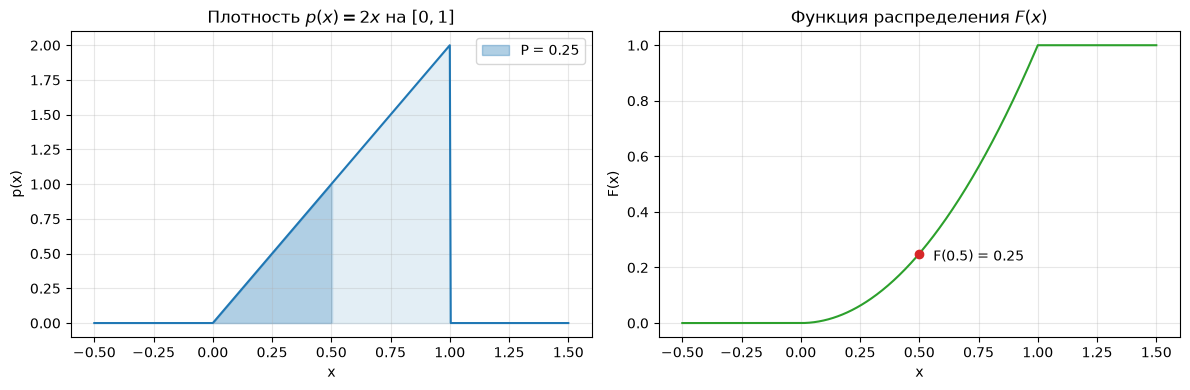

In [10]:
xs = np.linspace(-0.5, 1.5, 501)
pdf = np.where((xs >= 0) & (xs <= 1), 2 * xs, 0.0)
cdf = np.clip(xs, 0, 1)**2

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xs, pdf, color='tab:blue')
mask = (xs >= 0) & (xs <= 0.5)
ax[0].fill_between(xs[mask], pdf[mask], color='tab:blue', alpha=.35, label='P = 0.25')
ax[0].fill_between(xs[(xs > 0.5) & (xs <= 1)], pdf[(xs > 0.5) & (xs <= 1)], color='tab:blue', alpha=.12)
ax[0].set_title('Плотность $p(x)=2x$ на $[0,1]$'); ax[0].set_xlabel('x'); ax[0].set_ylabel('p(x)')
ax[0].grid(True, alpha=.3); ax[0].legend()

ax[1].plot(xs, cdf, color='tab:green')
ax[1].plot(0.5, 0.25, 'o', color='tab:red')
ax[1].annotate('F(0.5) = 0.25', (0.5, 0.25), textcoords='offset points', xytext=(10, -5))
ax[1].set_title('Функция распределения $F(x)$'); ax[1].set_xlabel('x'); ax[1].set_ylabel('F(x)')
ax[1].grid(True, alpha=.3)

plt.tight_layout(); plt.show()

---

### Задание 8**.


В задании 5 подберите прямую из множества **всех** прямых на плоскости, используя матричное решение метода наименьших квадратов: $w_{min} = (X^TX)^{-1}X^Ty$.

**Решение 8.**

Теперь прямая не обязана проходить через начало координат, поэтому параметров два: $y=w_0+w_1x$. Чтобы записать это матрично, добавляем к матрице объектов столбец из единиц (он «отвечает» за свободный член $w_0$):
$\displaystyle X=\begin{pmatrix}1&-3\\1&2\\1&5\end{pmatrix},\qquad y=\begin{pmatrix}2\\2\\-3\end{pmatrix},\qquad w=\begin{pmatrix}w_0\\w_1\end{pmatrix},$
и минимизируем $\;S(w)=\|y-Xw\|_2^2$. Из условия $\nabla_w S=-2X^\top(y-Xw)=0$ получаем нормальное уравнение $X^\top Xw=X^\top y$, откуда $w_{\min}=(X^\top X)^{-1}X^\top y$.

**Шаг 1.** Считаем $X^\top X$ и $X^\top y$ (здесь $n=3$, $\sum x_i=4$, $\sum x_i^2=38$, $\sum y_i=1$, $\sum x_iy_i=-17$):
$\displaystyle X^\top X=\begin{pmatrix}n&\sum x_i\\\sum x_i&\sum x_i^2\end{pmatrix}=\begin{pmatrix}3&4\\4&38\end{pmatrix},\qquad X^\top y=\begin{pmatrix}\sum y_i\\\sum x_iy_i\end{pmatrix}=\begin{pmatrix}1\\-17\end{pmatrix}.$

**Шаг 2.** Обращаем матрицу $2\times2$: $\det(X^\top X)=3\cdot38-4\cdot4=114-16=98\neq0$, значит обратная существует (точки не лежат на одной вертикали, столбцы $X$ линейно независимы):
$\displaystyle (X^\top X)^{-1}=\frac{1}{98}\begin{pmatrix}38&-4\\-4&3\end{pmatrix}.$

**Шаг 3.** Перемножаем:
$\displaystyle w_{\min}=\frac{1}{98}\begin{pmatrix}38&-4\\-4&3\end{pmatrix}\begin{pmatrix}1\\-17\end{pmatrix} =\frac{1}{98}\begin{pmatrix}38+68\\-4-51\end{pmatrix} =\frac{1}{98}\begin{pmatrix}106\\-55\end{pmatrix} =\begin{pmatrix}\tfrac{53}{49}\\[2pt]-\tfrac{55}{98}\end{pmatrix} \approx\begin{pmatrix}1.0816\\-0.5612\end{pmatrix}.$

**Ответ:** $\;y=\dfrac{53}{49}-\dfrac{55}{98}\,x\;\approx\;1.0816-0.5612\,x$.

**Сравнение с заданием 5.** Сумма квадратов отклонений здесь
$\displaystyle S=\Bigl(-\tfrac{75}{98}\Bigr)^2+\Bigl(\tfrac{100}{49}\Bigr)^2+\Bigl(-\tfrac{125}{98}\Bigr)^2=\frac{625}{98}\approx6.378,$
что меньше $\tfrac{357}{38}\approx9.395$ из задания 5. Это ожидаемо: прямые через начало координат — подмножество всех прямых, и добавление свободного члена не может ухудшить минимум. Побочное свойство модели со свободным членом: сумма остатков в точности равна нулю ($-\tfrac{75}{98}+\tfrac{200}{98}-\tfrac{125}{98}=0$) — этого у прямой через $(0,0)$ в общем случае нет (там $\sum e_i=1-(-\tfrac{17}{38})\cdot4\neq0$).

In [11]:
Xd = sp.Matrix([[1, -3], [1, 2], [1, 5]])
yd = sp.Matrix([2, 2, -3])

XtX, Xty = Xd.T * Xd, Xd.T * yd
print('X^T X ='); sp.pprint(XtX)
print('det =', XtX.det(), '   X^T y =', list(Xty))
print('(X^T X)^(-1) ='); sp.pprint(XtX.inv())

w = XtX.inv() * Xty
print('w = (w0, w1) =', list(w), '=', [float(t) for t in w])

resid = yd - Xd * w
print('остатки       =', list(resid))
print('сумма остатков =', sum(resid))
print('SSE (задание 8) =', (resid.T * resid)[0], '=', float((resid.T * resid)[0]))
print('SSE (задание 5) =', sp.Rational(357, 38), '=', float(sp.Rational(357, 38)))

# независимая численная проверка через МНК-решатель NumPy
w_np, *_ = np.linalg.lstsq(np.array(Xd, dtype=float), np.array(yd, dtype=float).ravel(), rcond=None)
print('numpy.linalg.lstsq:', w_np)

X^T X =
⎡3  4 ⎤
⎢     ⎥
⎣4  38⎦
det = 98    X^T y = [1, -17]
(X^T X)^(-1) =
⎡ 19         ⎤
⎢ ──    -2/49⎥
⎢ 49         ⎥
⎢            ⎥
⎣-2/49  3/98 ⎦
w = (w0, w1) = [53/49, -55/98] = [1.0816326530612246, -0.5612244897959183]
остатки       = [-75/98, 100/49, -125/98]
сумма остатков = 0
SSE (задание 8) = 625/98 = 6.377551020408164
SSE (задание 5) = 357/38 = 9.394736842105264
numpy.linalg.lstsq: [ 1.08163265 -0.56122449]


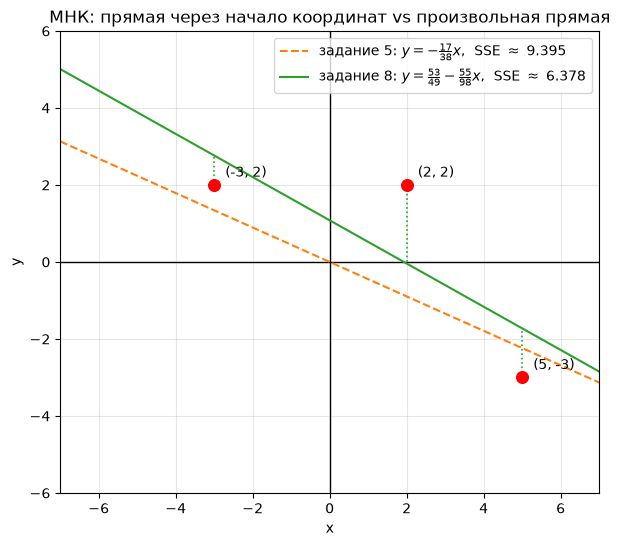

In [12]:
xs = np.linspace(-7, 7, 100)
w0, w1 = float(w[0]), float(w[1])

plt.figure(figsize=(7.5, 6))
plt.axhline(0, color='k', lw=1); plt.axvline(0, color='k', lw=1)
plt.scatter(X, Y, color='red', zorder=5, s=70)
for xi, yi in zip(X, Y):
    plt.annotate(f'({xi:.0f}, {yi:.0f})', (xi, yi), textcoords='offset points', xytext=(8, 6))

plt.plot(xs, float(k2) * xs, color='tab:orange', ls='--',
         label=r'задание 5: $y=-\frac{17}{38}x$,  SSE $\approx$ 9.395')
plt.plot(xs, w0 + w1 * xs, color='tab:green',
         label=r'задание 8: $y=\frac{53}{49}-\frac{55}{98}x$,  SSE $\approx$ 6.378')
for xi, yi in zip(X, Y):
    plt.plot([xi, xi], [yi, w0 + w1 * xi], ls=':', color='tab:green', lw=1.2)

plt.xlim(-7, 7); plt.ylim(-6, 6); plt.gca().set_aspect('equal')
plt.xlabel('x'); plt.ylabel('y')
plt.title('МНК: прямая через начало координат vs произвольная прямая')
plt.grid(True, alpha=.3); plt.legend(loc='upper right')
plt.show()